# Relax Inc. Take-Home Challenge

This notebook analyzes user engagement and adoption behavior for Relax Inc.

An adopted user is defined as a user who logged into the product on three separate days within at least one seven-day period.

The objective of this analysis is to identify factors associated with user adoption using exploratory analysis and predictive modeling techniques.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load Data

In [2]:
users = pd.read_csv("takehome_users.csv", encoding="latin1")
engagement = pd.read_csv("takehome_user_engagement.csv")

users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [3]:
engagement.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


## Initial Data Inspection

In [4]:
users.info()

print("\nMissing Values:")
print(users.isna().sum())

print("\nDuplicate Rows:")
print(users.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB

Missing Values:
object_id                        0
creation_time                    0
name                             0
email                

In [5]:
engagement.info()

print("\nMissing Values:")
print(engagement.isna().sum())

print("\nDuplicate Rows:")
print(engagement.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB

Missing Values:
time_stamp    0
user_id       0
visited       0
dtype: int64

Duplicate Rows:
0


## Define Adopted Users

In [6]:
engagement["time_stamp"] = pd.to_datetime(engagement["time_stamp"])

In [7]:
engagement = engagement.sort_values(by=["user_id", "time_stamp"])

In [8]:
adopted_users = []

for user_id in engagement["user_id"].unique():

    user_dates = engagement[engagement["user_id"] == user_id]["time_stamp"]

    user_dates = pd.to_datetime(user_dates.dt.date.unique())

    for start in range(len(user_dates) - 2):

        third_login = user_dates[start + 2]
        first_login = user_dates[start]

        if (third_login - first_login).days <= 7:

            adopted_users.append(user_id)
            break

In [9]:
users["adopted_user"] = users["object_id"].isin(adopted_users)

In [10]:
users["adopted_user"].value_counts()

adopted_user
False    10344
True      1656
Name: count, dtype: int64

In [11]:
users["adopted_user"].value_counts(normalize=True)

adopted_user
False    0.862
True     0.138
Name: proportion, dtype: float64

The adopted user label was created by identifying users who logged in on at least three separate days within a seven-day period. This label will be used as the target variable for the analysis.

## Exploratory Analysis

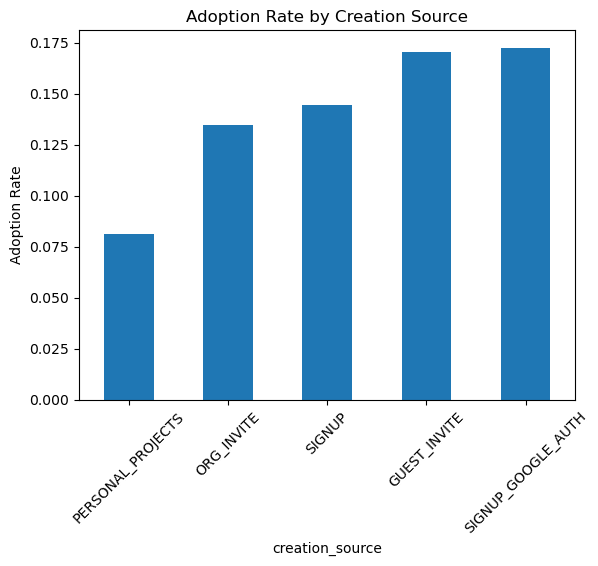

In [12]:
adoption_by_source = users.groupby("creation_source")["adopted_user"].mean()

adoption_by_source.sort_values().plot(kind="bar")

plt.ylabel("Adoption Rate")
plt.title("Adoption Rate by Creation Source")
plt.xticks(rotation=45)

plt.show()

In [13]:
users.groupby("opted_in_to_mailing_list")["adopted_user"].mean()

opted_in_to_mailing_list
0    0.136243
1    0.143287
Name: adopted_user, dtype: float64

In [14]:
users.groupby("enabled_for_marketing_drip")["adopted_user"].mean()

enabled_for_marketing_drip
0    0.137049
1    0.143415
Name: adopted_user, dtype: float64

### Key Exploratory Findings

Users who signed up through Google Authentication or guest invitations showed higher adoption rates compared to other signup methods.

Users associated with personal project invitations demonstrated the lowest adoption rates.

Marketing-related features such as mailing list participation and marketing drip enrollment showed only minor differences in adoption rates, suggesting they may not strongly influence long-term user engagement.

## Predictive Modeling

In [15]:
X = users.drop(columns=[
    "adopted_user",
    "name",
    "email",
    "object_id",
    "creation_time"
])

y = users["adopted_user"]

In [16]:
X["last_session_creation_time"] = X["last_session_creation_time"].fillna(0)

X["invited_by_user_id"] = X["invited_by_user_id"].fillna(0)

In [17]:
X = pd.get_dummies(X, drop_first=True)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13, stratify=y)

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [20]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [21]:
y_pred = log_reg.predict(X_test_scaled)

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6933333333333334

Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.67      0.79      2069
        True       0.29      0.87      0.44       331

    accuracy                           0.69      2400
   macro avg       0.63      0.77      0.61      2400
weighted avg       0.88      0.69      0.74      2400


Confusion Matrix:
[[1377  692]
 [  44  287]]


Because adopted users are the minority class, I used `class_weight="balanced"` to reduce the model’s tendency to predict only non-adopted users.

This substantially improved recall for adopted users, meaning the model identified nearly all true adopted users in the test set. However, precision was low, meaning many users predicted as adopted were actually not adopted.

This tradeoff may be acceptable if Relax Inc. wants to broadly identify users who are likely to adopt for low-cost outreach or engagement campaigns. If interventions are expensive, the model would need further tuning to improve precision.

In [23]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient
0,last_session_creation_time,22.980047
1,opted_in_to_mailing_list,0.024933
2,enabled_for_marketing_drip,-0.001034
3,org_id,0.195957
4,invited_by_user_id,0.042450
5,creation_source_ORG_INVITE,-0.161712
6,creation_source_PERSONAL_PROJECTS,-0.004600
7,creation_source_SIGNUP,-0.171041
8,creation_source_SIGNUP_GOOGLE_AUTH,-0.092144


The strongest predictor in the model was `last_session_creation_time`, suggesting that recent platform activity is strongly associated with adoption behavior. Other features demonstrated relatively smaller relationships with adoption likelihood.

## Key Findings

The analysis identified several factors associated with user adoption.

Users who signed up through organizational invitations and Google Authentication showed different adoption tendencies compared to other signup pathways. Marketing-related features demonstrated relatively weak relationships with adoption.

Because the dataset was imbalanced, a balanced logistic regression model was used to improve detection of adopted users. This significantly improved recall for the minority class, although precision decreased due to increased false positives.

The strongest predictor identified by the model was recent session activity, suggesting that continued platform engagement is strongly associated with adoption behavior.

## Recommendations and Further Research

Relax Inc. could potentially improve adoption rates by focusing on onboarding experience and long-term user engagement strategies.

Because organizational and authenticated signup pathways showed stronger adoption tendencies, the company may benefit from improving collaborative onboarding flows and reducing signup friction.

Future improvements could include:
- additional feature engineering
- testing alternative models such as Random Forests
- incorporating richer engagement metrics
- and optimizing classification thresholds to balance precision and recall based on business priorities.